In [9]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator
from typing import Callable
from sklearn.metrics import mean_absolute_error, accuracy_score, mean_absolute_percentage_error, r2_score, root_mean_squared_error
import pandas as pd
import bambi as bmb
import arviz as az
from scipy.stats import norm

# custom 
from utils import ts_parents, all_formulas_from_structures, train_regime_models_bayesian, classify_regime_bayesian, sliding_window_regime_prediction

In [4]:
# data with estimate regime from rpcmci and true regime for test data
data = pd.read_csv("data/simulated_time_series2.csv")

In [5]:
data

,X0,X1,X2,regime
0,0.257400,-0.908481,-0.378503,1
1,-0.704500,0.358427,-0.346381,1
2,0.323917,1.909899,0.665797,1
3,0.263321,0.626010,0.881800,1
4,-1.375531,-0.145202,0.941776,1
...,...,...,...,...
695,0.569862,0.016751,-2.061174,1
696,-0.090625,-1.771775,-0.854120,1
697,-2.112172,-0.746432,0.830971,1
698,-0.824656,-0.636239,-0.118933,1


In [6]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    # Regime 0
    0: {
        "X0": [(0, -1), (2,-1)],
        "X1": [(1, -1)],
        "X2": [(2, -1), (1, -1)],
        
    },
    # Regime 1
    1: {
        "X0": [(0, -1),(1,-1)],
        "X1": [(1, -1),(2,-1)],
        "X2": [(2, -1), (0, -1)],
    }
}

In [ ]:
#-- prepare training data
train = data[:500]
#-- filter training data by estimated regime
train1 = train[train['regime'] == 1].drop(columns=['regime'])
train0 = train[train['regime'] == 0].drop(columns=['regime'])
train1_features = ts_parents(train1, causal_structures[1])
train0_features = ts_parents(train0, causal_structures[0])
X_train = {0:train0_features,1:train1_features} # dataset for each regime

In [8]:
all_formulas = all_formulas_from_structures(causal_structures)

In [9]:
all_formulas

{0: {'X0': 'X0 ~ X0_lag1 + X2_lag1',
  'X1': 'X1 ~ X1_lag1',
  'X2': 'X2 ~ X2_lag1 + X1_lag1'},
 1: {'X0': 'X0 ~ X0_lag1 + X1_lag1',
  'X1': 'X1 ~ X1_lag1 + X2_lag1',
  'X2': 'X2 ~ X2_lag1 + X0_lag1'}}

In [10]:
bayesian_models = train_regime_models_bayesian(X=X_train, 
                                               all_formulas=all_formulas)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X0_sigma, Intercept, X0_lag1, X2_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 69 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X1_sigma, Intercept, X1_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 61 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X2_sigma, Intercept, X2_lag1, X1_lag1]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 59 seconds.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [X0_sigma, Intercept, X0_lag1, X1_lag1]
Sampling 4 chains for 1_000 tune and 

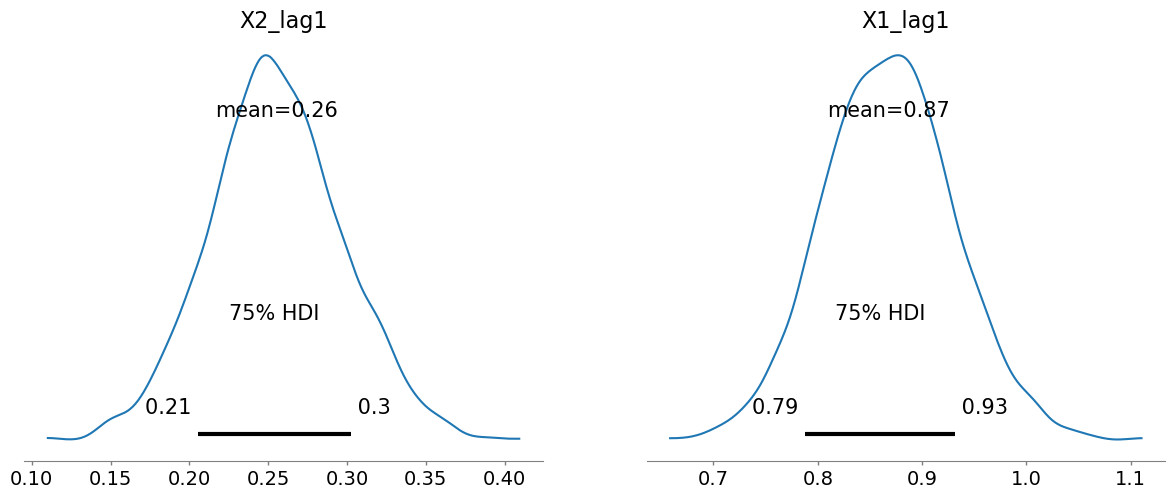

In [11]:
# Regime 0 posterior X2 
# 'X2': 'X2 ~ X2_lag1 + X1_lag1'
#-- regime_models: regime, variable, [model, idata]
az.plot_posterior(bayesian_models[0]["X2"]["idata"], var_names=['X2_lag1','X1_lag1'], hdi_prob=.75);

In [44]:
test = data[490:]
actual_regimes = test[['regime']]
test_data = test.drop(columns=['regime'])

test0 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[0]) 
test1 = ts_parents(df=test_data, 
                   causal_structure=causal_structures[1]) 

X_test = {0:test0,1:test1} # test dataset for each regime

In [45]:
regime_prediction, errors = classify_regime_bayesian(
    X_test=X_test, 
    all_formulas=all_formulas, 
    bayesian_models=bayesian_models,
    causal_structures=causal_structures
)

In [46]:
# classify regime 
w = 10
true_regime = actual_regimes[w:].values.reshape(-1,)
accuracy_score(regime_prediction[w-1:], true_regime)

0.77

In [47]:
# classify regime with a sliding window of the last w errors 
w = 10
window_preds = sliding_window_regime_prediction(errors, window_size=w)
true_regime = actual_regimes[w:].values.reshape(-1,)
accuracy_score(window_preds, true_regime)

0.98

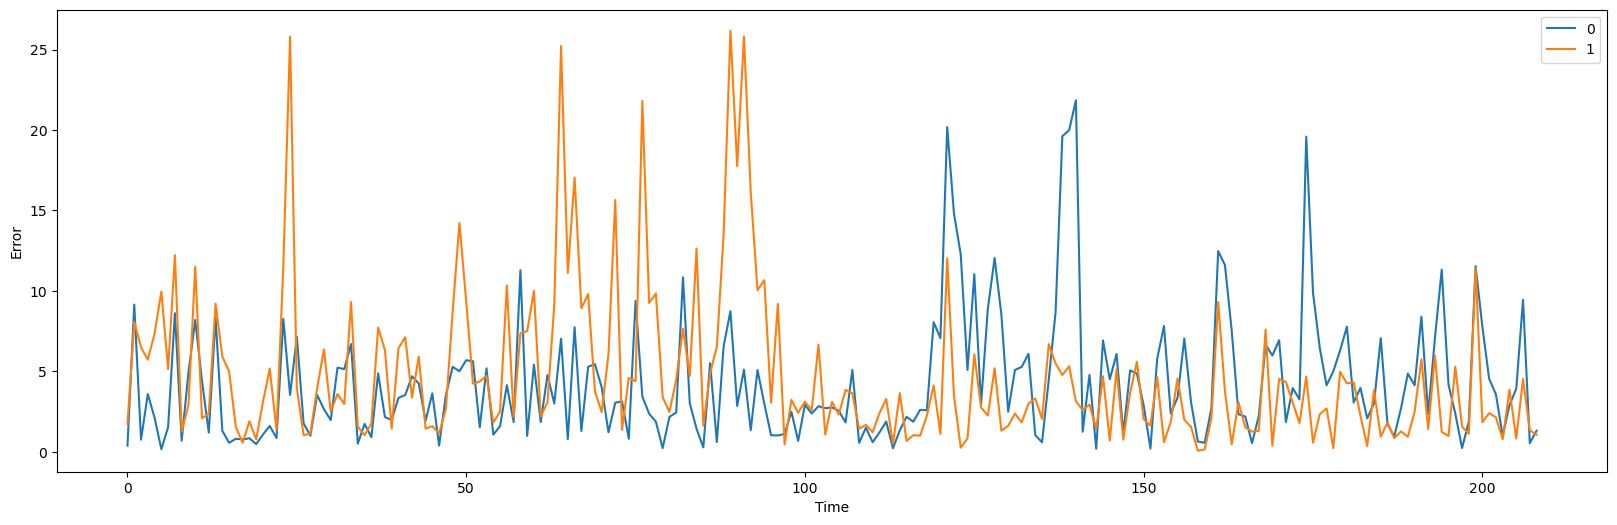

In [53]:
pd.DataFrame(errors).plot(figsize=(20,6), xlabel="Time", ylabel="Error");

# Forecasting

## CaReBayes (Causal Regime Bayesian Forecasting)

In [54]:
data

,X0,X1,X2,regime
0,0.257400,-0.908481,-0.378503,1
1,-0.704500,0.358427,-0.346381,1
2,0.323917,1.909899,0.665797,1
3,0.263321,0.626010,0.881800,1
4,-1.375531,-0.145202,0.941776,1
...,...,...,...,...
695,0.569862,0.016751,-2.061174,1
696,-0.090625,-1.771775,-0.854120,1
697,-2.112172,-0.746432,0.830971,1
698,-0.824656,-0.636239,-0.118933,1


In [61]:
window_preds.shape

(200,)

In [ ]:
# Make a deep copy
test_data = data.iloc[498:].copy()

#  Add a 'regime' column cleanly
test_data = test_data.reset_index(drop=True)  
test_data.loc[2:, 'regime'] = window_preds   

In [84]:
test_data

,X0,X1,X2,regime
0,-1.192799,-1.499417,-0.962212,0
1,-0.989217,-0.004685,-0.750942,0
2,0.715174,0.479827,-1.791654,0
3,0.839255,2.331222,0.969670,0
4,1.524782,2.383730,1.646396,0
...,...,...,...,...
197,0.569862,0.016751,-2.061174,1
198,-0.090625,-1.771775,-0.854120,1
199,-2.112172,-0.746432,0.830971,1
200,-0.824656,-0.636239,-0.118933,1


In [85]:
# shift regime one step (the previous classified regime it the causal structure for the forecast)
test_data['regime'] = test_data['regime'].shift(1)
test_data.dropna(inplace=True)

In [86]:
test_data

,X0,X1,X2,regime
1,-0.989217,-0.004685,-0.750942,0.0
2,0.715174,0.479827,-1.791654,0.0
3,0.839255,2.331222,0.969670,0.0
4,1.524782,2.383730,1.646396,0.0
5,2.439151,1.012001,2.267522,0.0
...,...,...,...,...
197,0.569862,0.016751,-2.061174,1.0
198,-0.090625,-1.771775,-0.854120,1.0
199,-2.112172,-0.746432,0.830971,1.0
200,-0.824656,-0.636239,-0.118933,1.0


In [87]:
test0 = ts_parents(test_data, causal_structures[0])
test1 = ts_parents(test_data, causal_structures[1])


test1_features= test1[test1['regime'] == 1].drop(columns=['regime'])
test0_features = test0[test0['regime'] == 0].drop(columns=['regime'])

In [138]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[0]["X2"]["model"]
idata = bayesian_models[0]["X2"]["idata"]


preds0 = model.predict(idata=idata, data=test0_features, kind="pps", inplace=False)
preds0 = preds0.posterior_predictive["X2"]  

mean_pred = preds0.mean(dim=("chain", "draw")).values
lower = preds0.quantile(0.025, dim=("chain", "draw")).values
upper = preds0.quantile(0.975, dim=("chain", "draw")).values

y_test = test0_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.49394168970937447
MAE: 0.7875272350799825
RMSE: 0.9802250202217528
MAPE: 1.8555647560089295


In [139]:
y_preds_total = []
upper_total = []
lower_total = []
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

In [151]:
# forecasting with bayesian autoregressive model 

# #-- bayesian_models: [regime], [variable], [model, idata]
#-- e.g., bayesian_models[0]["X2"]["idata"]
model = bayesian_models[1]["X2"]["model"]
idata = bayesian_models[1]["X2"]["idata"]


preds1 = model.predict(idata=idata, data=test1_features, kind="pps", inplace=False)
preds1 = preds1.posterior_predictive["X2"]  

mean_pred = preds1.mean(dim=("chain", "draw")).values
lower = preds1.quantile(0.025, dim=("chain", "draw")).values
upper = preds1.quantile(0.975, dim=("chain", "draw")).values

y_test = test1_features["X2"]
y_pred = mean_pred

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

R-squared (R2): 0.4582710947253845
MAE: 0.7887353712849486
RMSE: 0.9613821434452775
MAPE: 1.3640057261302097


In [152]:
y_preds_total.append(y_pred)
upper_total.append(upper) 
lower_total.append(lower)

In [153]:
bayesian_predictions = np.concatenate((y_preds_total[0], y_preds_total[1]))
bayesian_lower = np.concatenate((lower_total[0], lower_total[1]))
bayesian_upper = np.concatenate((upper_total[0], upper_total[1]))

In [154]:
bayesian_predictions.shape

(200,)

In [158]:
y_test = test["X2"].values

In [159]:
y_test.shape

(200,)

In [165]:
import numpy as np

def smape_metric(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return 100 * np.mean(numerator / np.clip(denominator, a_min=1e-8, a_max=None))

# Final CaReBayes Results

In [160]:
y_pred = bayesian_predictions.copy()
y_test = y_test

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = smape_metric(y_test, y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"SMAPE: {smape}")

R-squared (R2): 0.5118360116150236
MAE: 0.7880648556911923
RMSE: 0.9718850541866654
MAPE: 1.6368209877128992
SMAPE: 103.2044540296684


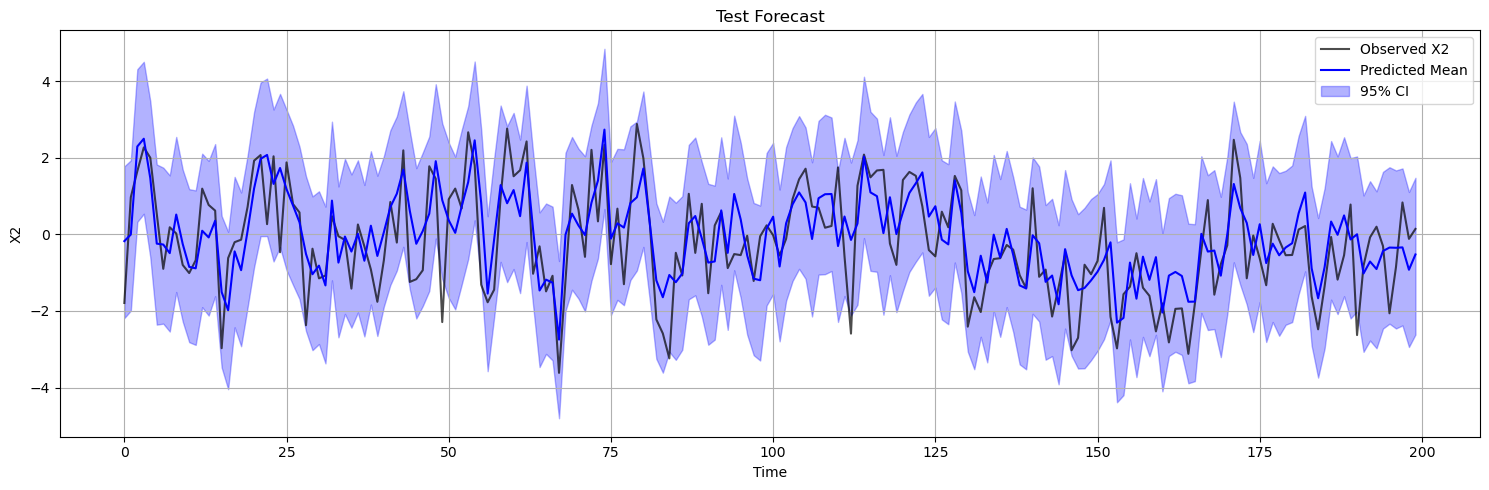

In [ ]:
plt.figure(figsize=(15, 5))

# Plot the observed values of X2
plt.plot(range(len(y_test)), y_test, label="Observed X2", color="black", alpha=0.7)

# Plot the predicted posterior mean
plt.plot(range(len(y_test)), bayesian_predictions, label="Predicted Mean", color="blue")

# Plot the uncertainty band (95% credible interval)
plt.fill_between(range(len(y_test)), bayesian_lower, bayesian_upper, color="blue", alpha=0.3, label="95% CI")

# Labels and legend
plt.legend()
plt.xlabel("Time")
plt.ylabel("X2")
plt.title("Test Forecast")
plt.grid(True)
plt.tight_layout()
plt.show()

# Benchmark Models

# VAR

In [4]:
from statsmodels.tsa.vector_ar.var_model import VAR
import pandas as pd
import numpy as np
# Load data
df = pd.read_csv('data/simulated_time_series2.csv')

# Split into training (0-499) and testing (500-699)
train = df.iloc[:499]
test  = df.iloc[499:700]


# Fit VAR(1) on training data
model = VAR(train)
res = model.fit(maxlags=1)

# One-step-ahead forecasts on test range
lag_order = res.k_ar
history = train.values.copy()
one_step_preds = []

for obs in test.values:
    # Forecast one step using last lag_order observations
    last_obs = history[-lag_order:]
    yhat = res.forecast(y=last_obs, steps=1)
    # Extract X2 prediction
    one_step_preds.append(yhat[0, 2])
    # Append the actual observation to history for next forecast
    history = np.vstack([history, obs])

# Convert forecasts to Series aligned with test index
forecast_series = pd.Series(one_step_preds, index=test.index)


In [14]:
y_test = test['X2'][1:]
y_pred = forecast_series[1:]


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)


# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")


R-squared (R2): 0.2909635774480962
MAE: 0.9442326080886503
RMSE: 1.1712950468896564
MAPE: 1.4159770011459065


# Regime-switching VAR

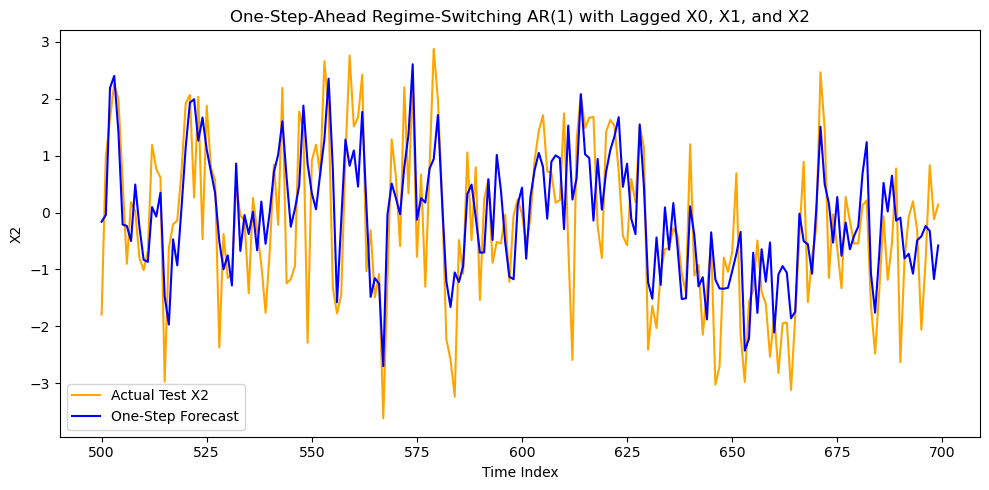

In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from scipy.stats import norm

# Load data
df = pd.read_csv('data/simulated_time_series2.csv')

# Create lag-1 features for X0, X1, and X2
df['X0_lag1'] = df['X0'].shift(1)
df['X1_lag1'] = df['X1'].shift(1)
df['X2_lag1'] = df['X2'].shift(1)

# Drop the first row with NaNs and reset index
df_lagged = df.dropna().reset_index(drop=True)

# Split into train (original 1–499) and test (500–699)
train = df_lagged.iloc[:499]
test  = df_lagged.iloc[499:]

# Training endogenous and exogenous
y_train = train['X2']
exog_train = train[['X0_lag1', 'X1_lag1', 'X2_lag1']]

# Fit 2-regime switching regression with lagged predictors
model = MarkovRegression(
    endog=y_train,
    k_regimes=2,
    exog=exog_train,
    trend='c',
    switching_trend=True,
    switching_exog=True,
    switching_variance=True
)
res = model.fit(em_iter=30, search_reps=10, disp=False)

# Extract parameters
params = res.params
P = np.array([
    [params['p[0->0]'], 1 - params['p[0->0]']],
    [params['p[1->0]'], 1 - params['p[1->0]']]
])
intercepts = np.array([params['const[0]'], params['const[1]']])
# Map exog lags: x1→X0_lag1, x2→X1_lag1, x3→X2_lag1
b_X0   = np.array([params['x1[0]'], params['x1[1]']])
b_X1   = np.array([params['x2[0]'], params['x2[1]']])
b_Ylag = np.array([params['x3[0]'], params['x3[1]']])
sigmas = np.sqrt(np.array([params['sigma2[0]'], params['sigma2[1]']]))

# Initialize filtered regime probabilities
pi = res.filtered_marginal_probabilities.iloc[-1].values

# One-step forecasts on the test set
one_step_preds = []
for _, row in test.iterrows():
    # 1) Regime-propagation
    pi_pred = pi.dot(P)
    # 2) Compute regime-specific means
    means = (intercepts +
             b_X0 * row['X0_lag1'] +
             b_X1 * row['X1_lag1'] +
             b_Ylag * row['X2_lag1'])
    # 3) Weighted average forecast
    y_hat = pi_pred.dot(means)
    one_step_preds.append(y_hat)
    # 4) Update pi with actual observation
    likelihoods = norm.pdf(row['X2'], loc=means, scale=sigmas)
    pi = pi_pred * likelihoods
    pi /= pi.sum()

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(df.index[500:], df['X2'][500:], label='Actual Test X2', color='orange')
plt.plot(df.index[500:], one_step_preds, label='One-Step Forecast', color='blue')
plt.xlabel('Time Index')
plt.ylabel('X2')
plt.title('One-Step-Ahead Regime-Switching AR(1) with Lagged X0, X1, and X2')
plt.legend()
plt.tight_layout()
plt.show()


In [195]:
y_test = df['X2'][500:]
y_pred = one_step_preds


# Evaluate the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
smape = smape_metric(y_test.to_numpy(), y_pred)

# Output the evaluation metrics
print(f"R-squared (R2): {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")
print(f"SMAPE: {smape}")

R-squared (R2): 0.4983069860008186
MAE: 0.799924504597065
RMSE: 0.9852604753937075
MAPE: 1.6710242526835934
SMAPE: 103.76650125699611
